In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras import layers
import sys
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
keras.utils.set_random_seed(41)

In [2]:
BASE_DATA_DIR = "C:\\Users\\danie\\PycharmProjects\\Untitled Folder"

In [3]:
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
import os
from tqdm import tqdm  # progress bar so you can see it working
AUDIO_DIR = "Student_train/"
CSV_PATH = 'Student_train.csv'
OUTPUT_DIR = "processed_audio"
df = pd.read_csv(os.path.join(BASE_DATA_DIR, CSV_PATH))
df

,ID,Labels
0,train 0,0
1,train 1,0
2,train 2,1
3,train 3,0
4,train 4,1
...,...,...
1605,train 1605,1
1606,train 1606,1
1607,train 1607,1
1608,train 1608,1


In [ ]:
if os.path.exists(os.path.join(BASE_DATA_DIR, OUTPUT_DIR)):
  pass
else:
  os.makedirs(os.path.join(BASE_DATA_DIR, OUTPUT_DIR) , exist_ok=True)
  for filename in os.listdir(os.path.join(BASE_DATA_DIR, AUDIO_DIR)):
    if filename.endswith(".wav"):
      audio, sr = librosa.load(os.path.join(BASE_DATA_DIR, AUDIO_DIR, filename), sr=16000, mono=True)
      audio = audio / (np.max(np.abs(audio)) + 1e-9) # peak normalization
      sf.write(os.path.join(BASE_DATA_DIR, OUTPUT_DIR, filename), audio, 16000)

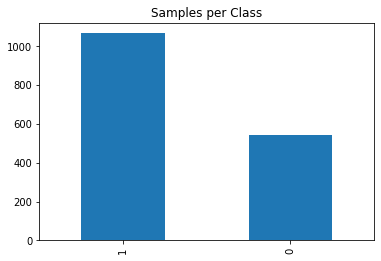

In [5]:
import seaborn as sns
import librosa.display
# Class distribution
df["Labels"].value_counts().plot(kind="bar")
plt.title("Samples per Class")
plt.show()

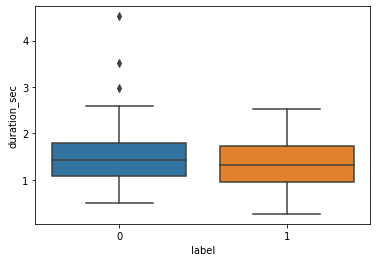

        count      mean       std       min       25%       50%       75%  \
label                                                                       
0       543.0  1.445795  0.464031  0.510750  1.083687  1.426562  1.786938   
1      1067.0  1.327530  0.460594  0.266437  0.957812  1.318375  1.736438   

            max  
label            
0      4.524750  
1      2.521063  


In [6]:
# Duration distribution per class

durations = []
for filename in os.listdir(os.path.join(BASE_DATA_DIR, OUTPUT_DIR)):
    if filename.endswith(".wav"):
        file_id = filename.replace(".wav", "")
        label = df.loc[df["ID"] == file_id, "Labels"].values[0]
        audio, sr = librosa.load(os.path.join(BASE_DATA_DIR, OUTPUT_DIR, filename), sr=16000)
        durations.append({"label": label, "duration_sec": len(audio) / sr})

dur_df = pd.DataFrame(durations)
sns.boxplot(data=dur_df, x="label", y="duration_sec")
plt.show()
print(dur_df.groupby("label")["duration_sec"].describe())

In [7]:
dur_df

,label,duration_sec
0,0,1.982438
1,0,1.150250
2,1,1.556500
3,1,1.397375
4,1,0.691625
...,...,...
1605,1,1.170063
1606,0,1.834625
1607,1,1.256625
1608,0,1.083687


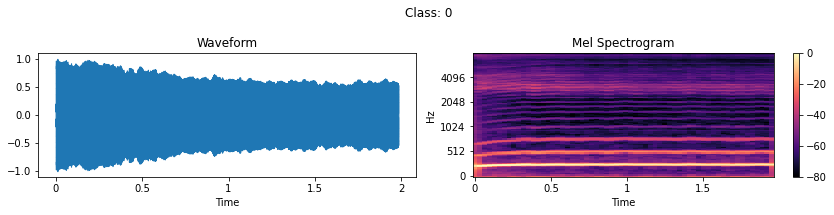

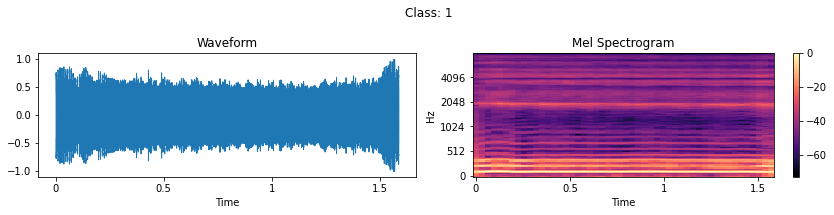

In [9]:
# Plot waveform + spectrogram for one sample per class

for label in df['Labels'].unique():
    sample = df[df["Labels"] == label].iloc[0]
    path = os.path.join(BASE_DATA_DIR, OUTPUT_DIR, sample['ID']+ ".wav")
    audio, sr = librosa.load(path, sr=16000)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    fig.suptitle(f"Class: {label}")
    
    # Waveform
    librosa.display.waveshow(audio, sr=sr, ax=axes[0])
    axes[0].set_title("Waveform")
    
    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time',
    y_axis='mel', ax=axes[1])
    axes[1].set_title("Mel Spectrogram")
    plt.colorbar(axes[1].collections[0], ax=axes[1])
    plt.tight_layout()
    plt.savefig(f"viz_{label}.png")
    plt.show()

In [10]:
FEATURES_DIR = "features"

if os.path.exists(os.path.join(BASE_DATA_DIR, FEATURES_DIR)):
  pass
else:
  os.makedirs(os.path.join(BASE_DATA_DIR, FEATURES_DIR) , exist_ok=True)

  for filename in os.listdir(os.path.join(BASE_DATA_DIR, OUTPUT_DIR)):
    if filename.endswith(".wav"):
      audio, sr = librosa.load(os.path.join(BASE_DATA_DIR, OUTPUT_DIR, filename), sr=16000)

      # Compute MFCCs on real audio BEFORE padding
      mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
      delta = librosa.feature.delta(mfccs)
      delta2 = librosa.feature.delta(mfccs, order=2)
      combined = np.concatenate([mfccs, delta, delta2], axis=0)  # shape: (120, 94)

      # Now pad the MFCC itself to fixed width
      target_frames = 94
      if combined.shape[1] < target_frames:
        combined = np.pad(combined, ((0, 0), (0, target_frames - combined.shape[1])))
      else:
        combined = combined[:, :target_frames]

      save_name = filename.replace(".wav", ".npy")
      np.save(os.path.join(BASE_DATA_DIR, FEATURES_DIR, save_name), combined)



(120, 94)
[[-1.7500212e+02 -1.4703395e+02 -1.4196411e+02 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 7.8181335e+01  6.9588547e+01  6.3579063e+01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 5.6340115e+01  5.2695133e+01  4.5188133e+01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [-3.8339618e-01 -3.8339618e-01 -3.8339618e-01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 3.1359571e-01  3.1359571e-01  3.1359571e-01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [-1.8988749e-02 -1.8988749e-02 -1.8988749e-02 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]]


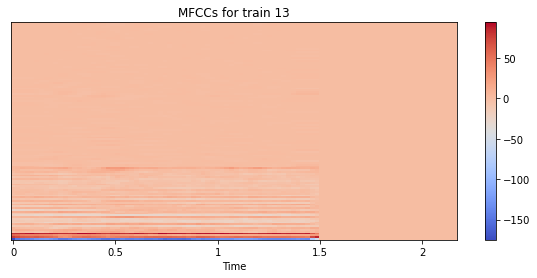

In [11]:
sample = np.load(os.path.join(BASE_DATA_DIR, FEATURES_DIR,"train 13.npy"))
print(sample.shape)  # shows (40, time_frames)
print(sample)

import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 4))
librosa.display.specshow(sample, x_axis='time')
plt.colorbar()
plt.title("MFCCs for train 13")
plt.show()

In [18]:
def augment_waveform(audio, sr):
    choice = np.random.randint(0, 3)

    if choice == 0:
        # Add noise
        noise = np.random.randn(len(audio)) * 0.003
        audio = audio + noise

    elif choice == 1:
        # Time stretch
        rate = np.random.uniform(0.9, 1.1)
        audio = librosa.effects.time_stretch(audio, rate=rate)

    elif choice == 2:
        # Pitch shift
        steps = np.random.randint(-2, 3)
        audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)

    return audio


def audio_to_mfcc(audio, sr, target_frames=94):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    # Handle short sequences safely
    time_dim = mfccs.shape[1]
    width = min(9, time_dim if time_dim % 2 != 0 else time_dim - 1)
    width = max(width, 3)  # minimum valid width

    delta = librosa.feature.delta(mfccs, width=width)
    delta2 = librosa.feature.delta(mfccs, order=2, width=width)

    combined = np.concatenate([mfccs, delta, delta2], axis=0)

    # Pad / truncate
    if combined.shape[1] < target_frames:
        combined = np.pad(combined, ((0, 0), (0, target_frames - combined.shape[1])))
    else:
        combined = combined[:, :target_frames]

    return combined

def normalize_sample(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-6)

In [19]:
y = df['Labels'].values
print(y)

[0 0 1 ... 1 1 1]


In [16]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, regularizers

# ── Build model function ──────────────────────────────────────────────

def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        
        layers.Dense(1, activation='sigmoid')
        ])
    model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
        )
    return model
model = build_model(input_shape=(120, 94, 1))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 120, 94, 32)       320       
                                                                 
 batch_normalization_2 (Batc  (None, 120, 94, 32)      128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 60, 47, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 60, 47, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 60, 47, 64)       256       
 hNormalization)                                                 
                                                      


── Fold 1 ──────────────────────

After data loading:
X_train shape: (3864, 120, 94)
X_val shape: (322, 120, 94)

After normalization:
Train min/max: -3.00, 3.00
Val min/max: -3.00, 3.00
Epoch 1/30
121/121 [==============================] - 35s 252ms/step - loss: 0.6638 - accuracy: 0.5885 - val_loss: 0.6887 - val_accuracy: 0.6553
Epoch 2/30
121/121 [==============================] - 30s 250ms/step - loss: 0.6168 - accuracy: 0.6589 - val_loss: 0.6974 - val_accuracy: 0.4130
Epoch 3/30
121/121 [==============================] - 30s 249ms/step - loss: 0.5897 - accuracy: 0.6843 - val_loss: 0.7390 - val_accuracy: 0.3416
Epoch 4/30
121/121 [==============================] - 30s 248ms/step - loss: 0.5695 - accuracy: 0.6946 - val_loss: 0.7453 - val_accuracy: 0.4099
Epoch 5/30
121/121 [==============================] - 31s 259ms/step - loss: 0.5501 - accuracy: 0.7140 - val_loss: 0.7557 - val_accuracy: 0.5062
Epoch 6/30
121/121 [==============================] - 30s 249ms/step - loss: 0.5277 - a

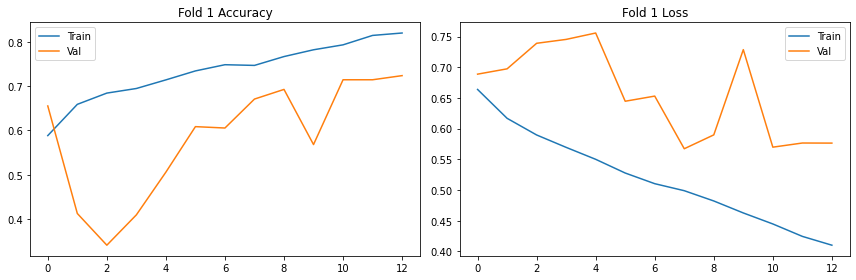


── Fold 2 ──────────────────────

After data loading:
X_train shape: (3864, 120, 94)
X_val shape: (322, 120, 94)

After normalization:
Train min/max: -3.00, 3.00
Val min/max: -3.00, 3.00
Epoch 1/30
121/121 [==============================] - 34s 247ms/step - loss: 0.6644 - accuracy: 0.5976 - val_loss: 0.6677 - val_accuracy: 0.6615
Epoch 2/30
121/121 [==============================] - 30s 244ms/step - loss: 0.6144 - accuracy: 0.6628 - val_loss: 0.6354 - val_accuracy: 0.6615
Epoch 3/30
121/121 [==============================] - 30s 244ms/step - loss: 0.5850 - accuracy: 0.6871 - val_loss: 0.6152 - val_accuracy: 0.6615
Epoch 4/30
121/121 [==============================] - 29s 240ms/step - loss: 0.5639 - accuracy: 0.7019 - val_loss: 0.5900 - val_accuracy: 0.6894
Epoch 5/30
121/121 [==============================] - 30s 247ms/step - loss: 0.5454 - accuracy: 0.7143 - val_loss: 0.5741 - val_accuracy: 0.6988
Epoch 6/30
121/121 [==============================] - 29s 238ms/step - loss: 0.5327 - a

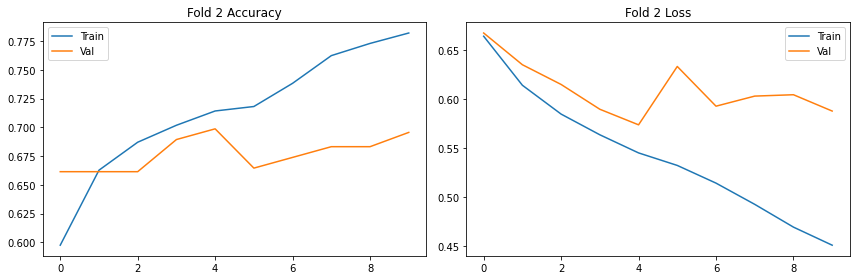


── Fold 3 ──────────────────────

After data loading:
X_train shape: (3864, 120, 94)
X_val shape: (322, 120, 94)

After normalization:
Train min/max: -3.00, 3.00
Val min/max: -3.00, 3.00
Epoch 1/30
121/121 [==============================] - 34s 245ms/step - loss: 0.6731 - accuracy: 0.5833 - val_loss: 0.7255 - val_accuracy: 0.3385
Epoch 2/30
121/121 [==============================] - 29s 236ms/step - loss: 0.6195 - accuracy: 0.6656 - val_loss: 0.7489 - val_accuracy: 0.3385
Epoch 3/30
121/121 [==============================] - 28s 235ms/step - loss: 0.5921 - accuracy: 0.6863 - val_loss: 0.7014 - val_accuracy: 0.4596
Epoch 4/30
121/121 [==============================] - 29s 238ms/step - loss: 0.5755 - accuracy: 0.6887 - val_loss: 0.7007 - val_accuracy: 0.4969
Epoch 5/30
121/121 [==============================] - 29s 238ms/step - loss: 0.5570 - accuracy: 0.7125 - val_loss: 0.6308 - val_accuracy: 0.6211
Epoch 6/30
121/121 [==============================] - 29s 237ms/step - loss: 0.5387 - a

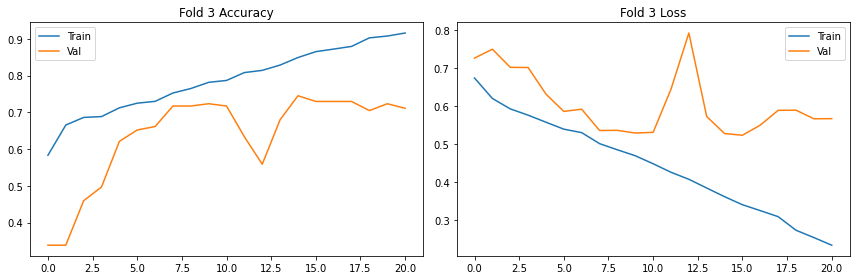


── Fold 4 ──────────────────────

After data loading:
X_train shape: (3864, 120, 94)
X_val shape: (322, 120, 94)

After normalization:
Train min/max: -3.00, 3.00
Val min/max: -3.00, 3.00
Epoch 1/30
121/121 [==============================] - 33s 243ms/step - loss: 0.6649 - accuracy: 0.5914 - val_loss: 0.6703 - val_accuracy: 0.6646
Epoch 2/30
121/121 [==============================] - 29s 239ms/step - loss: 0.6222 - accuracy: 0.6535 - val_loss: 0.6480 - val_accuracy: 0.6677
Epoch 3/30
121/121 [==============================] - 29s 236ms/step - loss: 0.5975 - accuracy: 0.6760 - val_loss: 0.6229 - val_accuracy: 0.7050
Epoch 4/30
121/121 [==============================] - 29s 235ms/step - loss: 0.5680 - accuracy: 0.6954 - val_loss: 0.6150 - val_accuracy: 0.6491
Epoch 5/30
121/121 [==============================] - 28s 235ms/step - loss: 0.5453 - accuracy: 0.7182 - val_loss: 0.6005 - val_accuracy: 0.6584
Epoch 6/30
121/121 [==============================] - 28s 235ms/step - loss: 0.5197 - a

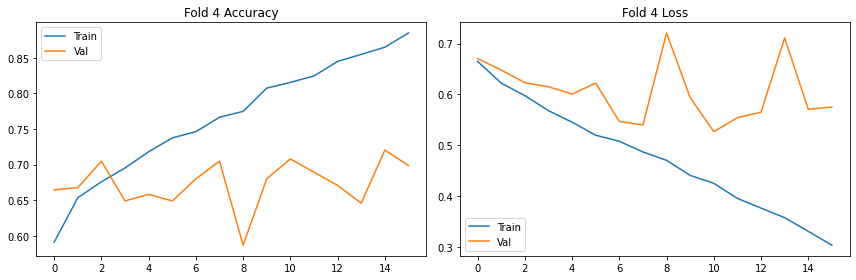


── Fold 5 ──────────────────────

After data loading:
X_train shape: (3864, 120, 94)
X_val shape: (322, 120, 94)

After normalization:
Train min/max: -3.00, 3.00
Val min/max: -3.00, 3.00
Epoch 1/30
121/121 [==============================] - 35s 259ms/step - loss: 0.6797 - accuracy: 0.5880 - val_loss: 0.6666 - val_accuracy: 0.6646
Epoch 2/30
121/121 [==============================] - 32s 263ms/step - loss: 0.6307 - accuracy: 0.6379 - val_loss: 0.6303 - val_accuracy: 0.6646
Epoch 3/30
121/121 [==============================] - 30s 246ms/step - loss: 0.6069 - accuracy: 0.6775 - val_loss: 0.6467 - val_accuracy: 0.6646
Epoch 4/30
121/121 [==============================] - 30s 246ms/step - loss: 0.5789 - accuracy: 0.6951 - val_loss: 0.6039 - val_accuracy: 0.6646
Epoch 5/30
121/121 [==============================] - 30s 246ms/step - loss: 0.5576 - accuracy: 0.7081 - val_loss: 0.5551 - val_accuracy: 0.7081
Epoch 6/30
121/121 [==============================] - 30s 246ms/step - loss: 0.5415 - a

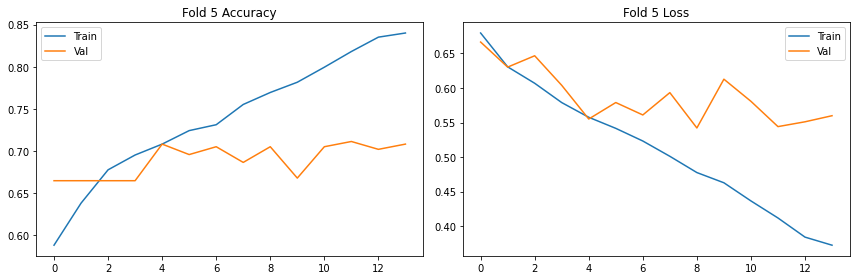


  FINAL CROSS-VALIDATION RESULTS
Mean Accuracy  : 0.7099 ± 0.0209
Mean Macro F1  : 0.6831 ± 0.0193
Per-fold F1s   : [0.6592, 0.6662, 0.7137, 0.6851, 0.6912]
Thresholds     : [0.59, 0.56, 0.555, 0.655, 0.6]
Mean threshold : 0.592


In [23]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import StratifiedKFold

fold_results = []
best_thresholds = []

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(df, y)):

    print(f"\n── Fold {fold+1} ──────────────────────")



    X_train, y_train = [], []
    X_val, y_val = [], []


    for idx in train_idx:
        filename = df.iloc[idx]['ID'] + ".wav"
        path = os.path.join(BASE_DATA_DIR, OUTPUT_DIR, filename)

        if not os.path.exists(path):
            continue

        # Load audio
        audio, sr = librosa.load(path, sr=16000)

        # ORIGINAL sample
        mfcc = audio_to_mfcc(audio, sr)
        X_train.append(mfcc)
        y_train.append(df.iloc[idx]['Labels'])

        # AUGMENTED samples (ONLY for training)
        for _ in range(2):
            audio_aug = augment_waveform(audio, sr)
            mfcc_aug = audio_to_mfcc(audio_aug, sr)

            X_train.append(mfcc_aug)
            y_train.append(df.iloc[idx]['Labels'])


    # BUILD VALIDATION DATA (NO augmentation!)

    for idx in val_idx:
        filename = df.iloc[idx]['ID'] + ".wav"
        path = os.path.join(BASE_DATA_DIR, OUTPUT_DIR, filename)

        if not os.path.exists(path):
            continue

        audio, sr = librosa.load(path, sr=16000)

        mfcc = audio_to_mfcc(audio, sr)

        X_val.append(mfcc)
        y_val.append(df.iloc[idx]['Labels'])

    # Convert to numpy
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_val = np.array(X_val)
    y_val = np.array(y_val)

    print("\nAfter data loading:")
    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    


    # CHANGE 2: Per-sample normalization (NO leakage)

    def normalize_sample(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-6)

    X_train = np.array([normalize_sample(x) for x in X_train])
    X_val   = np.array([normalize_sample(x) for x in X_val])

    # Optional stability trick
    X_train = np.clip(X_train, -3, 3)
    X_val   = np.clip(X_val, -3, 3)

    print("\nAfter normalization:")
    print(f"Train min/max: {X_train.min():.2f}, {X_train.max():.2f}")
    print(f"Val min/max: {X_val.min():.2f}, {X_val.max():.2f}")


    # Add CNN channel

    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]


    # Build model

    model = build_model(input_shape=(120, 94, 1))


    # Class weights (unchanged)

    from sklearn.utils.class_weight import compute_class_weight

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = dict(enumerate(class_weights))


    # Train

    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=32,
        validation_data=(X_val, y_val),
        class_weight=class_weights,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=1
    )

    # EVALUATION (MACRO F1)

    y_probs = model.predict(X_val, verbose=0).ravel()
 
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.2, 0.8, 121):
        preds = (y_probs > t).astype(int)
        mf1   = f1_score(y_val, preds, average="macro", zero_division=0)
        if mf1 > best_f1:
            best_f1, best_t = mf1, t
 
    best_thresholds.append(best_t)
    y_pred = (y_probs > best_t).astype(int)
    acc    = accuracy_score(y_val, y_pred)
    mf1    = f1_score(y_val, y_pred, average="macro", zero_division=0)
 
    print(f"\nFold {fold+1} → threshold={best_t:.2f} | "
          f"Accuracy={acc:.4f} | Macro F1={mf1:.4f}")
    fold_results.append((acc, mf1))


    # PLOTS

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'Fold {fold+1} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'Fold {fold+1} Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# ── CELL 10: Final summary ───────────────────────────────────
accs = [r[0] for r in fold_results]
f1s  = [r[1] for r in fold_results]
 
print("\n" + "="*50)
print("  FINAL CROSS-VALIDATION RESULTS")
print("="*50)
print(f"Mean Accuracy  : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean Macro F1  : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"Per-fold F1s   : {[round(f, 4) for f in f1s]}")
print(f"Thresholds     : {[round(t, 3) for t in best_thresholds]}")
print(f"Mean threshold : {np.mean(best_thresholds):.3f}")



In [24]:
# ── Train FINAL model on ALL data ───────────────────
.
 
print("\nTraining final model on ALL data...")

X_ids = df["ID"].values
y_all = df["Labels"].values

X_all_list, y_all_list = [], []
for i in range(len(df)):
    path = os.path.join(BASE_DATA_DIR, OUTPUT_DIR, X_ids[i] + ".wav")
    if not os.path.exists(path):
        continue
    audio, _ = librosa.load(path, sr=SR)
    X_all_list.append(normalize(audio_to_logmel(audio)))
    y_all_list.append(y_all[i])
    
    # One augmented copy
    X_all_list.append(normalize(audio_to_logmel(augment_audio(audio))))
    y_all_list.append(y_all[i])
 
X_all = np.array(X_all_list, dtype=np.float32)[..., np.newaxis]
y_all_final = np.array(y_all_list, dtype=np.int32)
 
cw_final    = compute_class_weight("balanced",
                                   classes=np.unique(y_all_final),
                                   y=y_all_final)
cw_final    = dict(enumerate(cw_final))

 
final_model = build_model(input_shape=(N_MELS, N_FRAMES, 1))
final_model.fit(
    X_all, y_all_final,
    epochs=40,
    batch_size=32,
    class_weight=cw_final,
    verbose=1,
)
 
FINAL_THRESHOLD = float(np.mean(best_thresholds))
print(f"\nFinal model trained. Using threshold: {FINAL_THRESHOLD:.3f}")
 
final_model.save("final_model.keras")
np.save("final_threshold.npy", np.array(FINAL_THRESHOLD))
print("Saved: final_model.keras  |  final_threshold.npy")
 

In [26]:
print("\nTraining FINAL model on ALL data...")

X_all, y_all = [], []

# BUILD FULL TRAINING DATASET (with augmentation)

for i in range(len(df)):

    filename = df.iloc[i]["ID"] + ".wav"
    path = os.path.join(BASE_DATA_DIR, OUTPUT_DIR, filename)

    if not os.path.exists(path):
        continue

    # Load audio
    audio, sr = librosa.load(path, sr=16000)

    # ORIGINAL sample
    mfcc = audio_to_mfcc(audio, sr)
    X_all.append(mfcc)
    y_all.append(df.iloc[i]["Labels"])

    # AUGMENTATION (same as KFold: 2 copies)
    for _ in range(2):
        audio_aug = augment_waveform(audio, sr)
        mfcc_aug = audio_to_mfcc(audio_aug, sr)

        X_all.append(mfcc_aug)
        y_all.append(df.iloc[i]["Labels"])


# Convert to numpy
X_all = np.array(X_all)
y_all = np.array(y_all)

print(f"\nFull dataset shape: {X_all.shape}")

# NORMALIZATION (same as CV avoid distribution shift)

def normalize_sample(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-6)

X_all = np.array([normalize_sample(x) for x in X_all])

# Clipping (stability)
X_all = np.clip(X_all, -3, 3)

# Add CNN channel dimension
X_all = X_all[..., np.newaxis]

# CLASS WEIGHTS (important for imbalance)

cw_final = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_all),
    y=y_all
)
cw_final = dict(enumerate(cw_final))

print("Class weights:", cw_final)


# BUILD MODEL

final_model = build_model(input_shape=(120, 94, 1))


# CALLBACKS ()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5),
]


# TRAIN FINAL MODEL

history = final_model.fit(
    X_all,
    y_all,
    validation_split=0.1,   # small hold-out for stability
    epochs=50,
    batch_size=32,
    class_weight=cw_final,
    callbacks=callbacks,
    verbose=1
)

final_threshold = np.median(best_thresholds)
final_model.save("final_model.keras")
print(f"Saved: final_model.keras  | median thrfeshold {final_threshold}")


Training FINAL model on ALL data...

Full dataset shape: (4830, 120, 94)
Class weights: {0: 1.4825046040515655, 1: 0.7544517338331771}
Epoch 1/50
136/136 [==============================] - 56s 311ms/step - loss: 0.6586 - accuracy: 0.5933 - val_loss: 0.6664 - val_accuracy: 0.6522 - lr: 1.0000e-04
Epoch 2/50
136/136 [==============================] - 36s 264ms/step - loss: 0.6118 - accuracy: 0.6646 - val_loss: 0.6583 - val_accuracy: 0.6522 - lr: 1.0000e-04
Epoch 3/50
136/136 [==============================] - 36s 263ms/step - loss: 0.5932 - accuracy: 0.6878 - val_loss: 0.6304 - val_accuracy: 0.6439 - lr: 1.0000e-04
Epoch 4/50
136/136 [==============================] - 37s 268ms/step - loss: 0.5743 - accuracy: 0.6904 - val_loss: 0.6249 - val_accuracy: 0.6522 - lr: 1.0000e-04
Epoch 5/50
136/136 [==============================] - 38s 279ms/step - loss: 0.5492 - accuracy: 0.7191 - val_loss: 0.6527 - val_accuracy: 0.6356 - lr: 1.0000e-04
Epoch 6/50
136/136 [==============================] - 

In [28]:
print(f"std threshold : {np.std(best_thresholds):.3f}")

std threshold : 0.036


In [ ]:
print("\nRunning predictions on TEST set...")

import os
import numpy as np
import pandas as pd
import librosa


# LOAD TEST CSV
test_CSV_PATH = os.path.join(BASE_DATA_DIR, 'Student_test.csv')
test_df = pd.read_csv(test_CSV_PATH)

print(f"Total test samples in CSV: {len(test_df)}")


# INITIALIZE CONTAINERS

X_test = []
ids = []


# SAFE NORMALIZATION FUNCTION (important fix)

def normalize_sample(x):
    std = np.std(x)
    if std < 1e-6:
        return np.zeros_like(x)   # avoids NaNs
    return (x - np.mean(x)) / std


# LOAD TEST DATA (NO augmentation!)

for i in range(len(test_df)):

    file_id = test_df.iloc[i]["ID"]
    filename = file_id + ".wav"
    path = os.path.join(BASE_DATA_DIR, "Student_test", filename)

    # Skip missing files
    if not os.path.exists(path):
        print(f"Missing file: {filename}")
        continue

    try:
        # Load audio
        audio, sr = librosa.load(path, sr=16000)
        audio = audio / (np.max(np.abs(audio)) + 1e-9) # peak normalization

        # Feature extraction (same as training)
        mfcc = audio_to_mfcc(audio, sr)

        # Skip bad samples (NaNs)
        if np.isnan(mfcc).any():
            print(f"NaNs in MFCC → skipping {filename}")
            continue

        X_test.append(mfcc)
        ids.append(file_id)

    except Exception as e:
        print(f"Error processing {filename}: {e}")
        continue


# CONVERT TO NUMPY

X_test = np.array(X_test)

print(f"\nFinal usable test samples: {len(X_test)}")
print(f"Feature shape: {X_test.shape}")


# NORMALIZATION (IDENTICAL TO TRAINING)

X_test = np.array([normalize_sample(x) for x in X_test])
X_test = np.clip(X_test, -3, 3)

# Add CNN channel dimension
X_test = X_test[..., np.newaxis]

# PREDICT

y_probs = final_model.predict(X_test, verbose=1).ravel()

# Safety check
print("\nNaN check:")
print("y_probs NaNs:", np.isnan(y_probs).sum())


# APPLY THRESHOLD (FROM K-FOLD)

y_pred = (y_probs > final_threshold).astype(int)


# SAVE RESULTS (THIS IS YOUR OUTPUT)

results_df = pd.DataFrame({
    "ID": ids,
    "Labels": y_pred,
})

output_path = "ee992_test set prediction.csv"
results_df.to_csv(output_path, index=False)

print(f"\nPredictions saved to: {output_path}")
print(results_df.head())
